<a href="https://colab.research.google.com/github/rezamarzban/antenna-graphs/blob/main/quick_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!apt install nec2c

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  nec2c
0 upgraded, 1 newly installed, 0 to remove and 24 not upgraded.
Need to get 122 kB of archives.
After this operation, 319 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 nec2c amd64 1.3-4 [122 kB]
Fetched 122 kB in 1s (93.0 kB/s)
Selecting previously unselected package nec2c.
(Reading database ... 121658 files and directories currently installed.)
Preparing to unpack .../archives/nec2c_1.3-4_amd64.deb ...
Unpacking nec2c (1.3-4) ...
Setting up nec2c (1.3-4) ...
Processing triggers for man-db (2.10.2-1) ...


In [2]:
%%writefile test.nec
GW 0 11 0. 0. 1.5 0. 0. 3 .005
GE -1
GN 2 0 0 0 3 0.0001
EK -1
FR 0 1 0 0 100.
EX 0 0 6 0 1.
LD 5 0 0 0 1390000 0
RP 0 90 90 0000 0 0 1 1
EN

Writing test.nec


In [3]:

!nec2c -i test.nec
!grep -A 4 "ANTENNA INPUT PARAMETERS" test.out
!grep -A 6 "POWER BUDGET" test.out

                        --------- ANTENNA INPUT PARAMETERS ---------
  TAG   SEG       VOLTAGE (VOLTS)         CURRENT (AMPS)         IMPEDANCE (OHMS)        ADMITTANCE (MHOS)     POWER
  No:   No:     REAL      IMAGINARY     REAL      IMAGINARY     REAL      IMAGINARY    REAL       IMAGINARY   (WATTS)
    0     6  1.0000E+00  0.0000E+00  8.7086E-03 -4.8924E-03  8.7282E+01  4.9034E+01  8.7086E-03 -4.8924E-03  4.3543E-03

                               ---------- POWER BUDGET ---------
                               INPUT POWER   =  4.3543E-03 Watts
                               RADIATED POWER=  4.3315E-03 Watts
                               STRUCTURE LOSS=  2.2752E-05 Watts
                               NETWORK LOSS  =  0.0000E+00 Watts
                               EFFICIENCY    =   99.48 Percent



In [4]:

!segments_n=11 && grep -A $((4 + $segments_n - 1)) "CURRENTS AND LOCATION" test.out | tail -$(($segments_n - 1)) | awk '{print $7}' > real_currents.txt

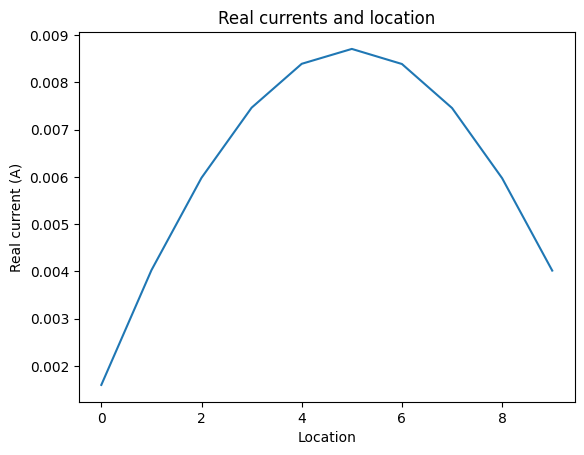

In [5]:

import matplotlib.pyplot as plt

# Read data from a text file
with open('real_currents.txt', 'r') as file:
    data = [float(line.strip()) for line in file]

# Create a basic plot
plt.plot(data)

# Add labels and title
plt.xlabel('Location')
plt.ylabel('Real current (A)')
plt.title('Real currents and location')

# Show the plot
plt.show()